In [2]:
import pandas as pd
import numpy as np
import datetime as dt
import random
import os
#import matplotlib.pyplot as plt

from datetime import datetime, timedelta


from core.data import load_from_kaggle

/home/ulfgar/Lehrgänge/Projekte/portfolio/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
dataset_link = "nokkyu/deutsche-bahn-db-delays" # replace with your dataset link from Kaggle 
destination = "../data/raw"
dataset_name = dataset_link.split("/")[-1]

files = load_from_kaggle(
    dataset_link=dataset_link, 
    destination=destination,
    )

Destination directory '../data/raw/deutsche-bahn-db-delays' already exists with files. Skipping download (replace=False).


In [4]:
df = pd.read_csv("/".join(["../data/raw/", dataset_name, files[0]]))
df.head()

,ID,line,path,eva_nr,category,station,state,city,zip,long,lat,arrival_plan,departure_plan,arrival_change,departure_change,arrival_delay_m,departure_delay_m,info,arrival_delay_check,departure_delay_check
0,1573967790757085557-2407072312-14,20,Stolberg(Rheinl)Hbf Gl.44|Eschweiler-St.Jöris|...,8000001,2,Aachen Hbf,Nordrhein-Westfalen,Aachen,52064,6.091499,50.767800,2024-07-08 00:00:00,2024-07-08 00:01:00,2024-07-08 00:03:00,2024-07-08 00:04:00,3,3,NaN,on_time,on_time
1,349781417030375472-2407080017-1,18,NaN,8000001,2,Aachen Hbf,Nordrhein-Westfalen,Aachen,52064,6.091499,50.767800,NaN,2024-07-08 00:17:00,NaN,NaN,0,0,NaN,on_time,on_time
2,7157250219775883918-2407072120-25,1,Hamm(Westf)Hbf|Kamen|Kamen-Methler|Dortmund-Ku...,8000406,4,Aachen-Rothe Erde,Nordrhein-Westfalen,Aachen,52066,6.116475,50.770202,2024-07-08 00:03:00,2024-07-08 00:04:00,2024-07-08 00:03:00,2024-07-08 00:04:00,0,0,NaN,on_time,on_time
3,349781417030375472-2407080017-2,18,Aachen Hbf,8000404,5,Aachen West,Nordrhein-Westfalen,Aachen,52072,6.070715,50.780360,2024-07-08 00:20:00,2024-07-08 00:21:00,NaN,NaN,0,0,NaN,on_time,on_time
4,1983158592123451570-2407080010-3,33,Herzogenrath|Kohlscheid,8000404,5,Aachen West,Nordrhein-Westfalen,Aachen,52072,6.070715,50.780360,2024-07-08 00:20:00,2024-07-08 00:21:00,2024-07-08 00:20:00,2024-07-08 00:21:00,0,0,NaN,on_time,on_time


In [5]:

# Nur DB-Daten für Leipzig Hbf am 2024-07-08
df["arrival_plan"] = pd.to_datetime(df["arrival_plan"])
df["departure_plan"] = pd.to_datetime(df["departure_plan"])
df_leipzig = df[df["station"] == "Leipzig Hbf"]
df_leipzig = df_leipzig[df_leipzig["departure_plan"].dt.date == pd.to_datetime("2024-07-08").date()]


In [6]:
n_bundesweit = 100
n_regional = 100
datum = pd.to_datetime("2024-07-08")

# Bundesweite fiktive Abfahrten zufällig über den Tag verteilt
abfahrts_bundes = [datum + timedelta(hours=np.random.randint(0,24), minutes=np.random.randint(0,60)) 
                   for _ in range(n_bundesweit)]
warte_bundes = np.random.randint(1,16, size=n_bundesweit)  # Wartezeiten in Minuten

# Regional (MDV) fiktive Abfahrten
abfahrts_regional = [datum + timedelta(hours=np.random.randint(0,24), minutes=np.random.randint(0,60)) 
                     for _ in range(n_regional)]
warte_regional = np.random.randint(1,16, size=n_regional)

# DataFrames
# Bundesweite fiktive Abfahrten
fiktiv_bundes = pd.DataFrame({
    "ursprungs_abfahrt": abfahrts_bundes,
    "trip_id": range(1000,1000+n_bundesweit),
    "best_departure": [t + timedelta(minutes=int(w)) for t,w in zip(abfahrts_bundes, warte_bundes)],
    "wartezeit_min": warte_bundes,
    "verspaetung_min": 0,
    "quelle": "MDV"
})

# Regionale fiktive Abfahrten
fiktiv_regional = pd.DataFrame({
    "ursprungs_abfahrt": abfahrts_regional,
    "trip_id": range(2000,2000+n_regional),
    "best_departure": [t + timedelta(minutes=int(w)) for t,w in zip(abfahrts_regional, warte_regional)],
    "wartezeit_min": warte_regional,
    "verspaetung_min": 0,
    "quelle": "MDV"
})


# Zusammenführen
fiktive_verbindungen = pd.concat([fiktiv_bundes, fiktiv_regional], ignore_index=True)
fiktive_verbindungen["departure_time_dt"] = fiktive_verbindungen["best_departure"]


In [7]:
# Verpasste Anschlüsse (nur Abfahrtszeiten > 0)
verpasste_anschluesse = df_leipzig[df_leipzig["departure_delay_m"] > 0].copy()
verpasste_anschluesse["trip_id"] = verpasste_anschluesse.index
verpasste_anschluesse["ursprungs_abfahrt"] = verpasste_anschluesse["departure_plan"]
verpasste_anschluesse["wartezeit_min"] = 0
verpasste_anschluesse["verspaetung_min"] = verpasste_anschluesse["departure_delay_m"]
verpasste_anschluesse["quelle"] = "DB"


In [8]:
def zeitabschnitt(dt):
    h = dt.hour
    if 6 <= h < 10:
        return "Früh (6–10)"
    elif 10 <= h < 14:
        return "Mittags (10–14)"
    elif 14 <= h < 18:
        return "Nachmittags (14–18)"
    elif 18 <= h < 22:
        return "Abends (18–22)"
    else:
        return "Nacht (22–6)"

# Tageszeit für DB + MDV
verpasste_anschluesse["tageszeit"] = verpasste_anschluesse["ursprungs_abfahrt"].apply(zeitabschnitt)
fiktive_verbindungen["tageszeit"] = fiktive_verbindungen["ursprungs_abfahrt"].apply(zeitabschnitt)


In [9]:
vergleich_df = pd.concat([verpasste_anschluesse[["ursprungs_abfahrt","verspaetung_min","wartezeit_min","quelle","tageszeit"]],
                          fiktive_verbindungen[["ursprungs_abfahrt","verspaetung_min","wartezeit_min","quelle","tageszeit"]]],
                         ignore_index=True)

# Gruppieren nach Quelle + Tageszeit
vergleich_summary = vergleich_df.groupby(["quelle","tageszeit"]).agg(
    avg_verspaetung=("verspaetung_min","mean"),
    max_verspaetung=("verspaetung_min","max"),
    avg_wartezeit=("wartezeit_min","mean"),
    max_wartezeit=("wartezeit_min","max"),
    anzahl=("ursprungs_abfahrt","count")
).round(2)

print(vergleich_summary)


                            avg_verspaetung  max_verspaetung  avg_wartezeit  \
quelle tageszeit                                                              
DB     Abends (18–22)                  2.50                6           0.00   
       Früh (6–10)                     1.00                1           0.00   
       Mittags (10–14)                 1.00                1           0.00   
       Nachmittags (14–18)             3.29                7           0.00   
       Nacht (22–6)                    1.00                1           0.00   
MDV    Abends (18–22)                  0.00                0           8.25   
       Früh (6–10)                     0.00                0           7.27   
       Mittags (10–14)                 0.00                0           8.25   
       Nachmittags (14–18)             0.00                0           8.74   
       Nacht (22–6)                    0.00                0           8.21   

                            max_wartezeit  anzahl  

In [10]:
def hat_schnittpunkt(db_path, alt_path):
    # db_path: Liste der Stationen der DB-Verbindung
    # alt_path: Liste der Stationen der Alternativverbindung
    db_stops = db_path.split("|")
    alt_stops = alt_path.split("|")
    return any(stop in alt_stops for stop in db_stops)


In [11]:
alternative_list = []

for idx, db_row in verpasste_anschluesse.iterrows():
    db_path = db_row["path"]
    db_departure = db_row["departure_change"]  # bei DB Verspätung
    
    # Kandidaten: MDV und bundesweite fiktive Verbindungen
    for _, alt_row in fiktive_verbindungen.iterrows():
        if hat_schnittpunkt(db_path, alt_row["path"]):
            alt_departure = alt_row["best_departure"]
            wartezeit = (alt_departure - db_departure).total_seconds() / 60
            if wartezeit >= 0:  # nur spätere Abfahrten
                alternative_list.append({
                    "ursprungs_abfahrt": db_departure,
                    "alternativ_abfahrt": alt_departure,
                    "wartezeit_min": wartezeit,
                    "quelle": alt_row["quelle"]
                })



KeyError: 'path'

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

# -----------------------------
# 1️⃣ Grunddaten vorbereiten
# -----------------------------
# Beispielhaft: wir nehmen dein vorhandenes DB-Delay-DataFrame df
verpasste_anschluesse = df.copy()

# Nur sinnvolle Spalten behalten
verpasste_anschluesse = verpasste_anschluesse[[
    "line", "path", "station", "departure_plan", "departure_change", "departure_delay_m"
]].dropna(subset=["departure_plan", "departure_change"])

# Zeitspalten konvertieren
verpasste_anschluesse["departure_plan"] = pd.to_datetime(verpasste_anschluesse["departure_plan"])
verpasste_anschluesse["departure_change"] = pd.to_datetime(verpasste_anschluesse["departure_change"])

# -----------------------------
# 2️⃣ Fiktive MDV & bundesweite Verbindungen erzeugen
# -----------------------------
n_bundesweit = 100
n_regional = 100
datum = pd.Timestamp("2024-07-08")

def random_abfahrten(n):
    return [datum + timedelta(hours=random.randint(0,23), minutes=random.randint(0,59)) for _ in range(n)]

# Fiktive Pfade simulieren
def fake_path():
    stops = ["Leipzig Hbf","Halle(Saale)Hbf","Bitterfeld","Naumburg(Saale)Hbf","Eilenburg","Delitzsch"]
    return "|".join(random.sample(stops, k=random.randint(2,4)))

fiktiv_bundes = pd.DataFrame({
    "trip_id": range(1000, 1000+n_bundesweit),
    "ursprungs_abfahrt": random_abfahrten(n_bundesweit),
    "best_departure": random_abfahrten(n_bundesweit),
    "wartezeit_min": [random.randint(1,20) for _ in range(n_bundesweit)],
    "verspaetung_min": [random.choice([0,1,2,5]) for _ in range(n_bundesweit)],
    "path": [fake_path() for _ in range(n_bundesweit)],
    "quelle": "MDV"
})

fiktiv_regional = pd.DataFrame({
    "trip_id": range(2000, 2000+n_regional),
    "ursprungs_abfahrt": random_abfahrten(n_regional),
    "best_departure": random_abfahrten(n_regional),
    "wartezeit_min": [random.randint(1,15) for _ in range(n_regional)],
    "verspaetung_min": [random.choice([0,1,3]) for _ in range(n_regional)],
    "path": [fake_path() for _ in range(n_regional)],
    "quelle": "DB"
})

fiktive_verbindungen = pd.concat([fiktiv_bundes, fiktiv_regional], ignore_index=True)

# -----------------------------
# 3️⃣ Schnittpunkt-Logik
# -----------------------------
def hat_schnittpunkt(db_path, alt_path):
    if pd.isna(db_path) or pd.isna(alt_path):
        return False
    db_stops = set(str(db_path).split("|"))
    alt_stops = set(str(alt_path).split("|"))
    return len(db_stops.intersection(alt_stops)) > 0

# -----------------------------
# 4️⃣ Alternative finden
# -----------------------------
alternative_list = []

for _, db_row in verpasste_anschluesse.iterrows():
    db_path = db_row["path"]
    db_departure = db_row["departure_change"]

    # Kandidaten: alle späteren Alternativen mit Schnittpunkten
    kandidaten = fiktive_verbindungen[
        fiktive_verbindungen["path"].apply(lambda p: hat_schnittpunkt(db_path, p))
    ]

    for _, alt in kandidaten.iterrows():
        wartezeit = (alt["best_departure"] - db_departure).total_seconds() / 60
        if 0 <= wartezeit <= 120:  # nur realistische Zeitfenster
            alternative_list.append({
                "ursprungs_abfahrt": db_departure,
                "wartezeit_min": wartezeit,
                "verspaetung_min": alt["verspaetung_min"],
                "quelle": alt["quelle"]
            })

alternativen_df = pd.DataFrame(alternative_list)
print(f"✅ {len(alternativen_df)} Alternativen mit Pfadschnittpunkten gefunden.\n")

# -----------------------------
# 5️⃣ Tageszeiten kategorisieren
# -----------------------------
def zeitabschnitt(dt):
    h = dt.hour
    if 6 <= h < 10: return "Früh (6–10)"
    elif 10 <= h < 14: return "Mittags (10–14)"
    elif 14 <= h < 18: return "Nachmittags (14–18)"
    elif 18 <= h < 22: return "Abends (18–22)"
    else: return "Nacht (22–6)"

alternativen_df["tageszeit"] = alternativen_df["ursprungs_abfahrt"].apply(zeitabschnitt)

# -----------------------------
# 6️⃣ Tabellarische Auswertung
# -----------------------------
vergleich = alternativen_df.groupby(["quelle", "tageszeit"]).agg(
    avg_verspaetung=("verspaetung_min","mean"),
    max_verspaetung=("verspaetung_min","max"),
    avg_wartezeit=("wartezeit_min","mean"),
    max_wartezeit=("wartezeit_min","max"),
    anzahl=("wartezeit_min","count")
).round(2)

print("📊 Vergleich DB vs. MDV nach Tageszeit:\n")
print(vergleich)

# 7️⃣ Empfehlung je Tageszeit
# -----------------------------

empfehlungen_liste = []

for tageszeit, gruppe in vergleich.groupby("tageszeit"):
    # Mittelwerte pro Quelle ermitteln
    db_warte = gruppe.loc[gruppe["quelle"] == "DB", "avg_wartezeit"].values
    mdv_warte = gruppe.loc[gruppe["quelle"] == "MDV", "avg_wartezeit"].values

    # Absicherung gegen fehlende Werte
    if len(db_warte) == 0 or len(mdv_warte) == 0:
        empfehlung = "Keine Daten"
    else:
        if db_warte[0] < mdv_warte[0]:
            empfehlung = "DB im Vorteil"
        elif mdv_warte[0] < db_warte[0]:
            empfehlung = "MDV im Vorteil"
        else:
            empfehlung = "Gleichstand"

    empfehlungen_liste.append({
        "tageszeit": tageszeit,
        "DB_Ø_Wartezeit": db_warte[0] if len(db_warte) else None,
        "MDV_Ø_Wartezeit": mdv_warte[0] if len(mdv_warte) else None,
        "Empfehlung": empfehlung
    })

empfehlungen_df = pd.DataFrame(empfehlungen_liste)

print("🧭 Empfehlung je Tageszeit:")
display(empfehlungen_df)



✅ 23681 Alternativen mit Pfadschnittpunkten gefunden.

📊 Vergleich DB vs. MDV nach Tageszeit:

                            avg_verspaetung  max_verspaetung  avg_wartezeit  \
quelle tageszeit                                                              
DB     Abends (18–22)                  1.41                3          56.74   
       Früh (6–10)                     1.72                3          63.17   
       Mittags (10–14)                 1.08                3          54.83   
       Nachmittags (14–18)             1.62                3          64.48   
       Nacht (22–6)                    0.99                3          57.68   
MDV    Abends (18–22)                  2.20                5          55.76   
       Früh (6–10)                     1.99                5          60.09   
       Mittags (10–14)                 2.63                5          57.76   
       Nachmittags (14–18)             1.57                5          66.77   
       Nacht (22–6)                 

KeyError: 'quelle'

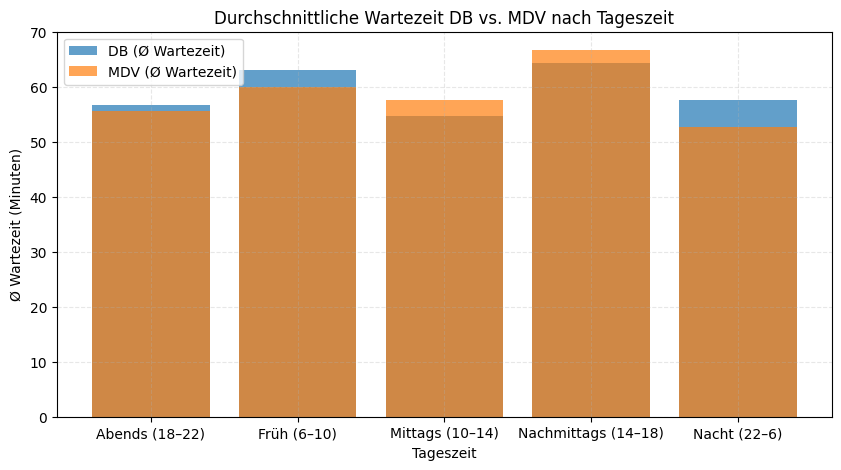

In [ ]:
import matplotlib.pyplot as plt

vergleich.reset_index(inplace=True)

plt.figure(figsize=(10,5))
for quelle in ["DB", "MDV"]:
    teil = vergleich[vergleich["quelle"] == quelle]
    plt.bar(
        teil["tageszeit"], teil["avg_wartezeit"], alpha=0.7,
        label=f"{quelle} (Ø Wartezeit)"
    )

plt.title("Durchschnittliche Wartezeit DB vs. MDV nach Tageszeit")
plt.xlabel("Tageszeit")
plt.ylabel("Ø Wartezeit (Minuten)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()
